In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ngwkhai/vietnamese-stock-market-data")

print("Path to dataset files:", path)

100%|██████████| 1.06M/1.06M [00:01<00:00, 1.09MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/ngwkhai/vietnamese-stock-market-data/versions/3


# Stock Price Prediction using RNN and LSTM
Bài toán: Dự báo giá đóng cửa (Close) của 7 mã cổ phiếu Việt Nam dựa trên dữ liệu lịch sử.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Cấu hình visualization
%matplotlib inline
sns.set(style='whitegrid')

## 2. Load Dataset



In [ ]:
import os
import pandas as pd
import kagglehub
import glob

try:
    if 'path' not in locals():
        path = kagglehub.dataset_download("ngwkhai/vietnamese-stock-market-data")

    # Tìm tất cả các file giá (price) trong thư mục preprocessed_data
    price_files = glob.glob(os.path.join(path, "**", "preprocessed_data", "*_price.csv"), recursive=True)

    if price_files:
        all_dfs = []
        for f in price_files:
            temp_df = pd.read_csv(f)
            # Lấy ticker từ tên file nếu trong file không có cột ticker
            if 'ticker' not in temp_df.columns:
                ticker_name = os.path.basename(f).split('_')[1]
                temp_df['ticker'] = ticker_name
            all_dfs.append(temp_df)

        df = pd.concat(all_dfs, ignore_index=True)
        # Chuẩn hóa tên cột để khớp với logic tiền xử lý
        # Giả sử file có cột 'date', ta đổi thành 'trading_date'
        if 'date' in df.columns:
            df = df.rename(columns={'date': 'trading_date'})

        print(f"Đã gộp thành công {len(price_files)} file dữ liệu giá.")
        print(f"Các mã hiện có: {df['ticker'].unique()}")
        display(df.head())
    else:
        print("Không tìm thấy file dữ liệu giá (_price.csv) nào.")
except Exception as e:
    print(f"Lỗi: {e}")

Đã gộp thành công 7 file dữ liệu giá.
Các mã hiện có: ['MSN' 'MWG' 'IMP' 'HPG' 'VNM' 'FPT' 'GAS']


,NGÀY,GIÁ MỞ CỬA,GIÁ CAO NHẤT,GIÁ THẤP NHẤT,GIÁ ĐÓNG CỬA,THAY ĐỔI GIÁ,% THAY ĐỔI,KHỐI LƯỢNG,ticker
0,14/03/2025,70500.0,71900.0,70400.0,71100.0,700.0,0.009943,7301100,MSN
1,13/03/2025,68700.0,71200.0,68700.0,70400.0,1700.0,0.024745,11573600,MSN
2,12/03/2025,68900.0,69700.0,68700.0,68700.0,-200.0,-0.002903,4987800,MSN
3,11/03/2025,68200.0,68900.0,68100.0,68900.0,0.0,0.000000,4533500,MSN
4,10/03/2025,69000.0,69900.0,68700.0,68900.0,-100.0,-0.001449,5117800,MSN


## 3. Data Preprocessing
Chúng ta sẽ làm sạch dữ liệu, chọn 7 mã cổ phiếu tiêu biểu và chuẩn hóa.

In [ ]:
if 'df' in locals():
    # 1. Tiền xử lý dữ liệu
    df['trading_date'] = pd.to_datetime(df['NGÀY'], dayfirst=True)
    df['close'] = df['GIÁ ĐÓNG CỬA']
    df = df.sort_values(['ticker', 'trading_date'])

    top_tickers = df['ticker'].unique()[:7]
    print(f"7 mã cổ phiếu phân tích: {top_tickers}")

    def create_sequences(data, window_size=60):
        X, y = [], []
        for i in range(len(data) - window_size):
            X.append(data[i:(i + window_size)])
            y.append(data[i + window_size])
        return np.array(X), np.array(y)

    stock_data_processed = {}
    for ticker in top_tickers:
        data_ticker = df[df['ticker'] == ticker]['close'].values.reshape(-1, 1)
        ticker_scaler = MinMaxScaler(feature_range=(0, 1))
        scaled_data = ticker_scaler.fit_transform(data_ticker)

        train_size = int(len(scaled_data) * 0.8)
        train_data = scaled_data[:train_size]
        test_data = scaled_data[train_size:]

        window = 60
        X_train, y_train = create_sequences(train_data, window)
        X_test, y_test = create_sequences(test_data, window)

        stock_data_processed[ticker] = {
            'X_train': X_train, 'y_train': y_train,
            'X_test': X_test, 'y_test': y_test,
            'scaler': ticker_scaler
        }
    print("Tiền xử lý hoàn tất.")
else:
    print("Vui lòng chạy cell load dữ liệu trước.")

7 mã cổ phiếu phân tích: ['FPT' 'GAS' 'HPG' 'IMP' 'MSN' 'MWG' 'VNM']
Tiền xử lý hoàn tất.


## 4. Build and Train Models
Chúng ta sẽ xây dựng hàm để tạo mô hình Simple RNN và LSTM, sau đó huấn luyện cho từng mã cổ phiếu.

In [ ]:
def build_improved_rnn(input_shape):
    model = Sequential([
        tf.keras.layers.Input(shape=input_shape),
        SimpleRNN(100, activation='tanh', return_sequences=True),
        Dropout(0.2),
        SimpleRNN(50, activation='tanh', return_sequences=False),
        Dropout(0.2),
        Dense(25), Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

results = {}
print("--- Bắt đầu huấn luyện Simple RNN ---")
for ticker in top_tickers:
    print(f"\nĐang huấn luyện mã: {ticker}")
    d = stock_data_processed[ticker]
    model = build_improved_rnn((60, 1))

    model.fit(d['X_train'], d['y_train'], epochs=30, batch_size=32, validation_split=0.1,
              callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)], verbose=1)

    y_pred = d['scaler'].inverse_transform(model.predict(d['X_test'], verbose=0))
    y_true = d['scaler'].inverse_transform(d['y_test'].reshape(-1, 1))

    results[ticker] = {'actual': y_true, 'rnn_pred': y_pred}
    results[ticker]['RNN_metrics'] = (mean_absolute_error(y_true, y_pred), np.sqrt(mean_squared_error(y_true, y_pred)),
                                      np.mean(np.abs((y_true - y_pred) / y_true)) * 100, r2_score(y_true, y_pred))

print("\nHoàn tất huấn luyện toàn bộ RNN!")

--- Bắt đầu huấn luyện Simple RNN ---

Đang huấn luyện mã: FPT
Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 0.1040 - val_loss: 0.0284
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0253 - val_loss: 0.0017
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0118 - val_loss: 0.0064
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0088 - val_loss: 0.0025
Epoch 5/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0065 - val_loss: 0.0027
Epoch 6/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0058 - val_loss: 0.0052
Epoch 7/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 0.0046 - val_loss: 0.0045

Đang huấn luyện mã: GAS
Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 0.4387 - val_loss: 0.0064
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0883 - val_loss: 0.0070
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0516 - val_loss: 0.0032
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0


Đang huấn luyện mã: IMP
Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 0.1017 - val_loss: 0.0011
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0244 - val_loss: 0.0011
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0113 - val_loss: 4.2777e-04
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0083 - val_loss: 4.9020e-04
Epoch 5/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0061 - val_loss: 6.2345e-04
Epoch 6/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0063 - val_loss: 0.0013
Epoch 7/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0043 - val_loss: 3.6338e-04
Epoch 8/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0036 - val_loss: 5.5826e-04
Epoch 9/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0033 - val_loss: 4.3217e-04
Epoch 10/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0027 - val_loss: 2.7138e-04
Epoch 11/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0025 - val_loss: 8.6253e-04
Epoch 

In [ ]:
def build_improved_lstm(input_shape):
    model = Sequential([
        tf.keras.layers.Input(shape=input_shape),
        LSTM(100, activation='tanh', return_sequences=True),
        Dropout(0.2),
        LSTM(50, activation='tanh', return_sequences=False),
        Dropout(0.2),
        Dense(25),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

print("--- Bắt đầu huấn luyện LSTM ---")
for ticker in top_tickers:
    print(f"\nĐang huấn luyện mã: {ticker}")
    d = stock_data_processed[ticker]
    # The input shape needs to be derived from the actual data for consistency.
    # Using d['X_train'].shape[1:] instead of a fixed (60, 1) to be more robust
    # if the window size changes.
    model = build_improved_lstm(d['X_train'].shape[1:])

    model.fit(d['X_train'], d['y_train'], epochs=30, batch_size=32, validation_split=0.1,
              callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)], verbose=1)

    y_pred = d['scaler'].inverse_transform(model.predict(d['X_test'], verbose=0))
    results[ticker]['lstm_pred'] = y_pred
    results[ticker]['LSTM_metrics'] = (mean_absolute_error(results[ticker]['actual'], y_pred),
                                       np.sqrt(mean_squared_error(results[ticker]['actual'], y_pred)),
                                       np.mean(np.abs((results[ticker]['actual'] - y_pred) / results[ticker]['actual'])) * 100,
                                       r2_score(results[ticker]['actual'], y_pred))

print("\nHoàn tất huấn luyện toàn bộ LSTM!")

--- Bắt đầu huấn luyện LSTM ---

Đang huấn luyện mã: FPT
Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - loss: 0.0064 - val_loss: 0.0082
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.0015 - val_loss: 0.0098
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - loss: 0.0010 - val_loss: 0.0023
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - loss: 8.4008e-04 - val_loss: 0.0018
Epoch 5/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 8.0442e-04 - val_loss: 0.0015
Epoch 6/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 6.6446e-04 - val_loss: 0.0026
Epoch 7/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 5.7491e-04 - val_loss: 0.0016
Epoch 8/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - loss: 5.9747e-04 - val_loss: 0.0032
Epoch 9/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 6.8160e-04 - val_loss: 0.0025
Epoch 10/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - loss: 6.2738e-04 - val_loss: 0.0024

Đang huấn luyện mã: GAS
Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━

In [ ]:
def build_improved_lstm(input_shape):
    model = Sequential([
        tf.keras.layers.Input(shape=input_shape),
        LSTM(100, activation='tanh', return_sequences=True),
        Dropout(0.2),
        LSTM(50, activation='tanh', return_sequences=False),
        Dropout(0.2),
        Dense(25),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

print("--- Bắt đầu huấn luyện LSTM (Cải tiến) ---")
for ticker in top_tickers:
    print(f"\nĐang huấn luyện mã: {ticker}")
    data = stock_data_processed[ticker]
    input_shape = (data['X_train'].shape[1], 1)

    model = build_improved_lstm(input_shape)
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    model.fit(data['X_train'], data['y_train'], epochs=50, batch_size=32,
              validation_split=0.1, callbacks=[early_stop], verbose=1)

    # Dự báo
    pred = model.predict(data['X_test'], verbose=0)
    scaler = data['scaler']
    y_true = scaler.inverse_transform(data['y_test'].reshape(-1, 1))
    y_pred = scaler.inverse_transform(pred)

    # Tính Metric
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)

    # Lưu vào kết quả chung
    results[ticker]['LSTM'] = (mae, rmse, mape, r2)
    results[ticker]['lstm_pred'] = y_pred
    print(f"Ticker {ticker}: LSTM Done (MAE: {mae:.2f})")

print("\nHoàn tất huấn luyện toàn bộ LSTM!")

--- Bắt đầu huấn luyện LSTM (Cải tiến) ---

Đang huấn luyện mã: FPT
Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - loss: 0.0077 - val_loss: 0.0147
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0018 - val_loss: 0.0011
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 9.4368e-04 - val_loss: 0.0021
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - loss: 7.9977e-04 - val_loss: 0.0011
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 6.9350e-04 - val_loss: 0.0014
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 6.4876e-04 - val_loss: 0.0013
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - loss: 5.7471e-04 - val_loss: 8.6921e-04
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 5.9044e-04 - val_loss: 9.6129e-04
Epoch 9/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - loss: 4.9785e-04 - val_loss: 0.0034
Epoch 10/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - loss: 4.6179e-04 - val_loss: 0.0010
Epoch 11/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 

## 5. Visualization and Comparison
So sánh kết quả dự báo giữa RNN và LSTM trên đồ thị và bảng metric.

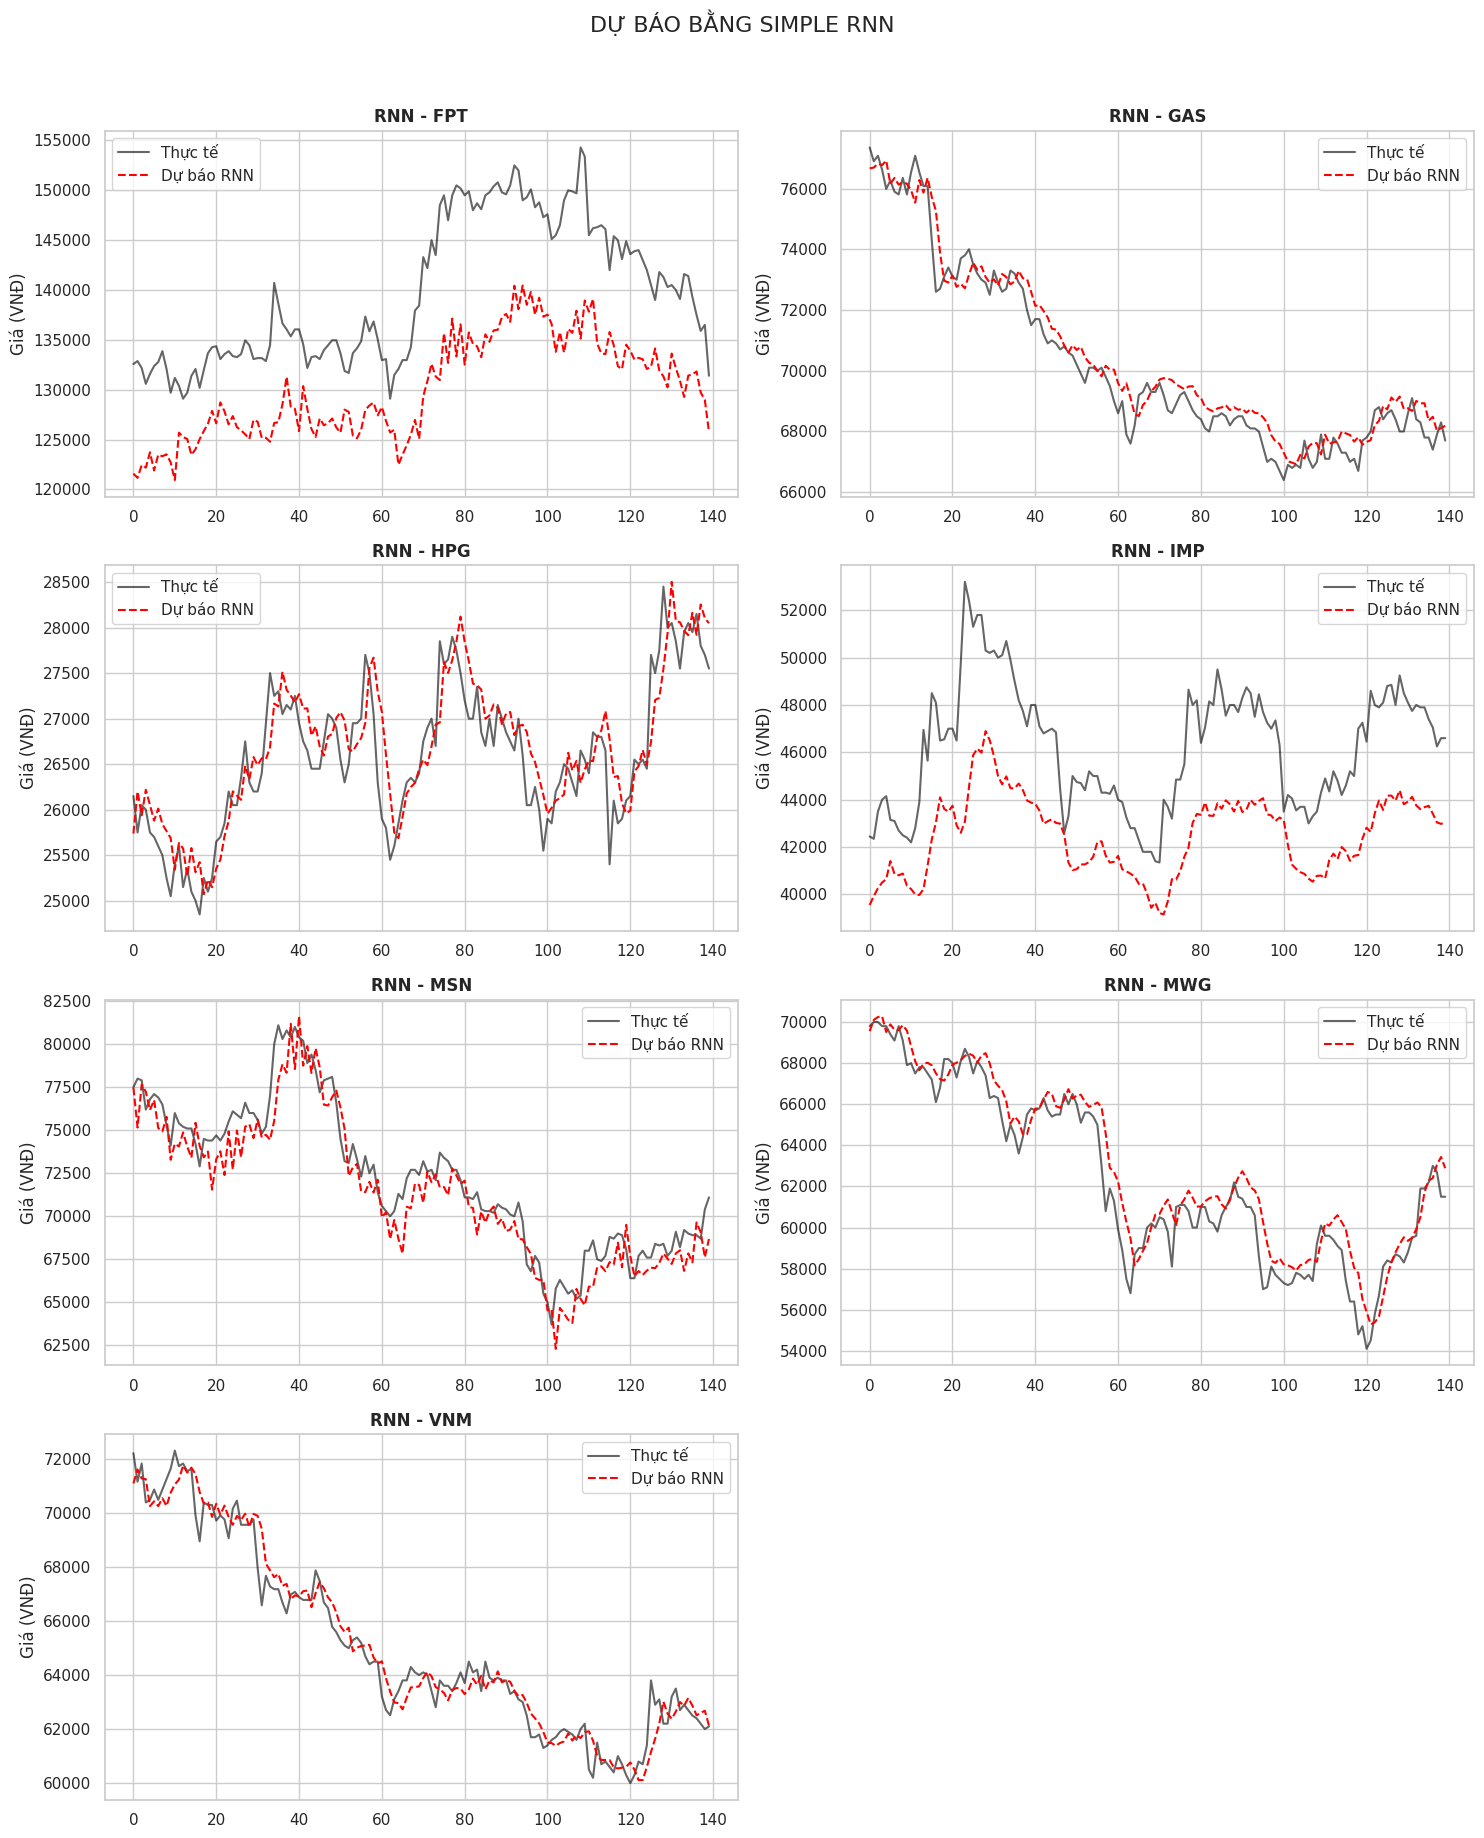

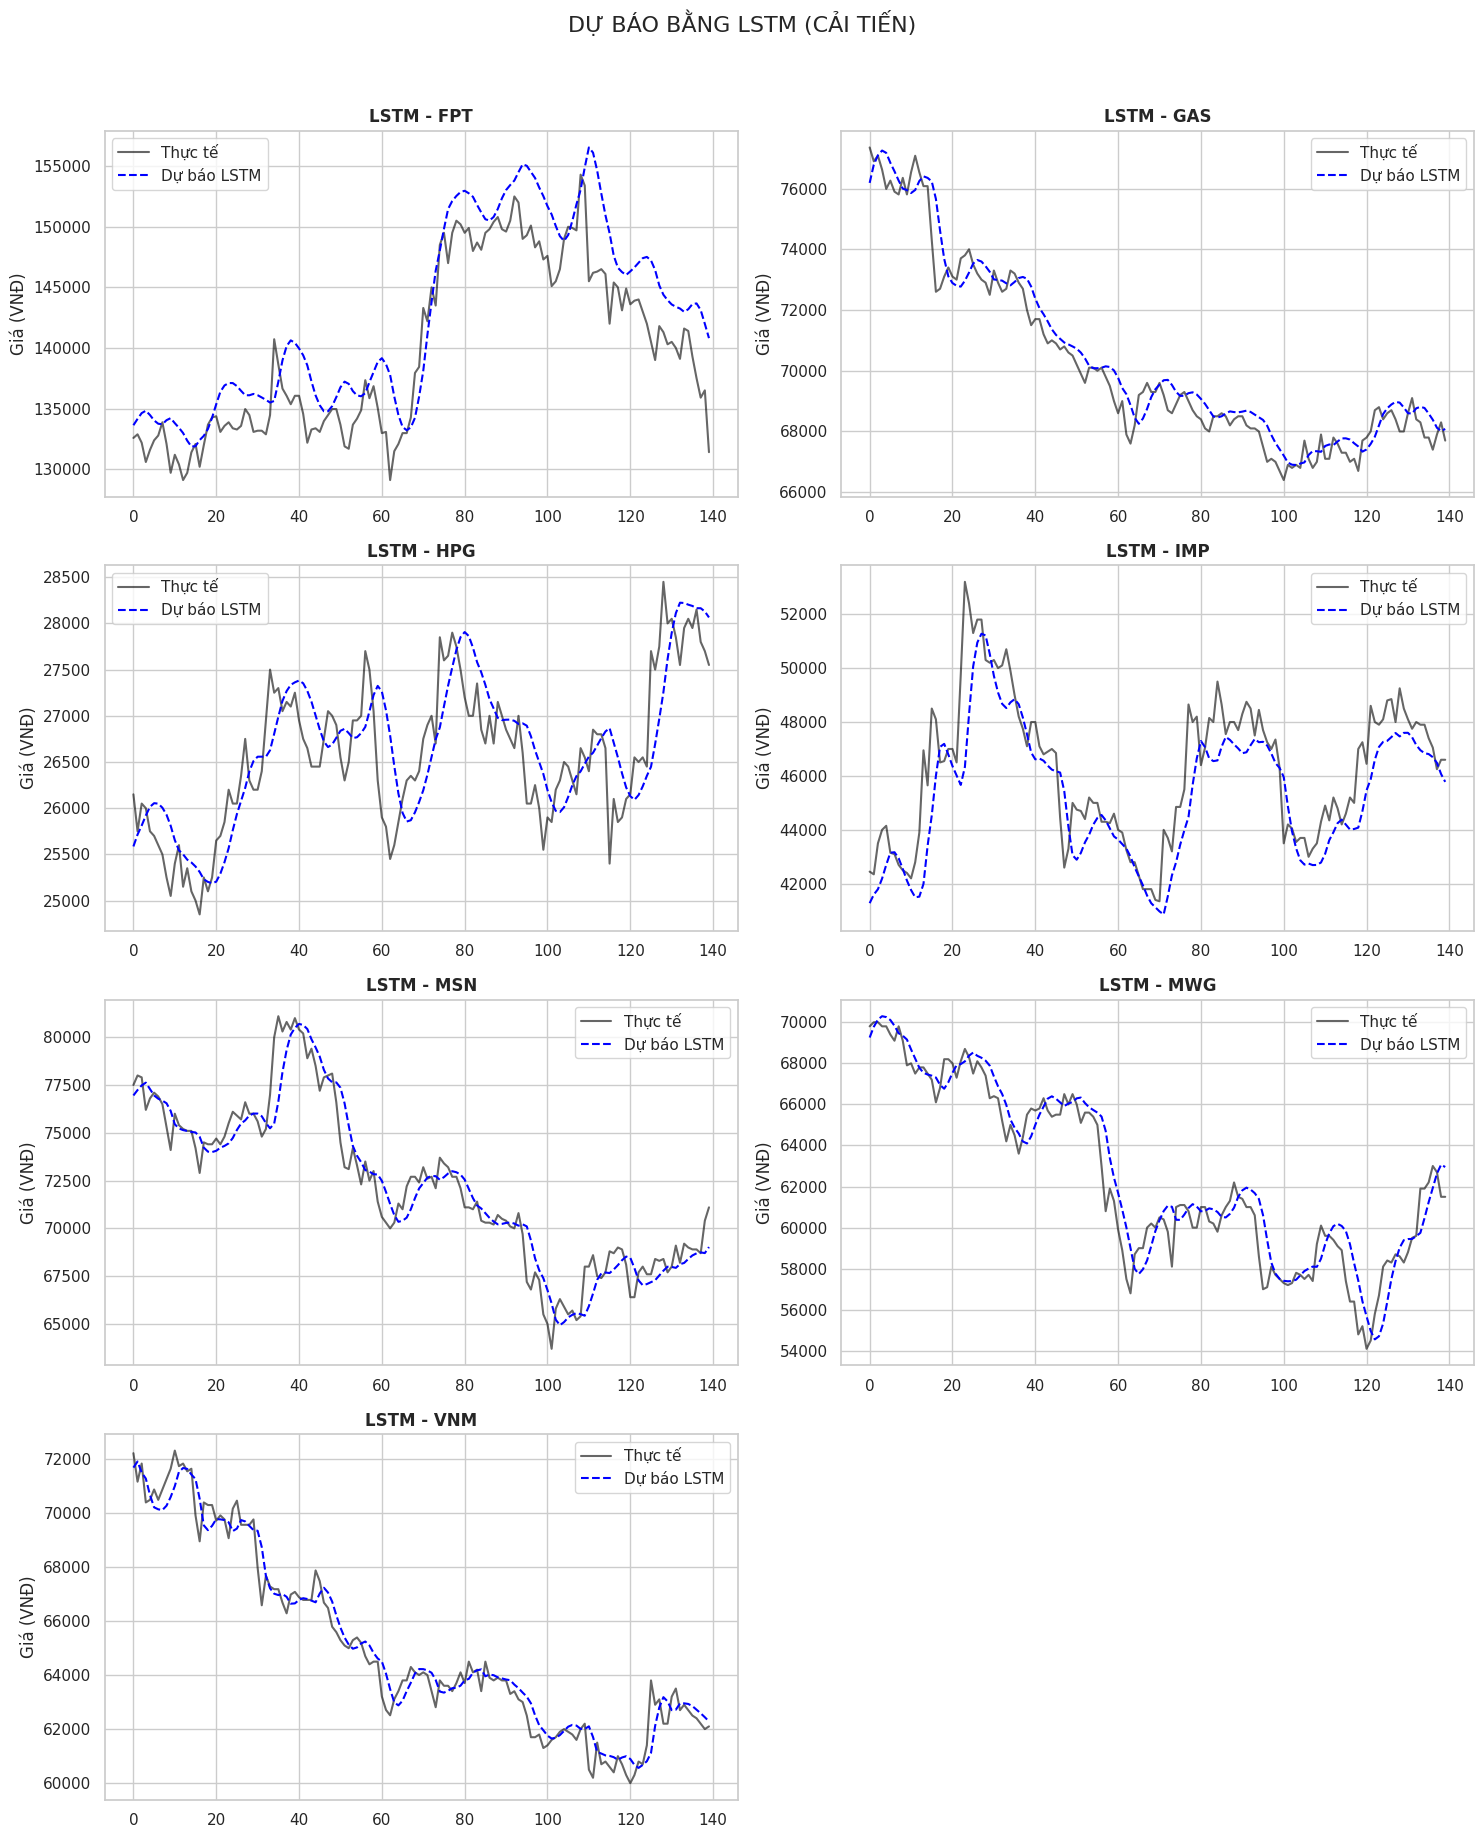


BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ SIMPLE RNN:


,Mã CK,MAE,RMSE,MAPE (%),R2 Score
0,FPT,9583.38,10118.91,6.79%,-1.0393
1,GAS,533.28,664.52,0.76%,0.9493
2,HPG,310.49,398.34,1.17%,0.7421
3,IMP,3698.80,3949.92,7.90%,-1.3307
4,MSN,1229.99,1498.24,1.70%,0.8703
5,MWG,897.46,1180.82,1.48%,0.9210
6,VNM,518.93,695.18,0.80%,0.9586



BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ LSTM (CẢI TIẾN):


,Mã CK,MAE,RMSE,MAPE (%),R2 Score
0,FPT,2753.70,3577.47,1.96%,0.7451
1,GAS,649.31,803.81,0.93%,0.9258
2,HPG,538.09,657.42,2.04%,0.2976
3,IMP,3026.37,3574.17,6.41%,-0.9084
4,MSN,1110.97,1486.51,1.53%,0.8723
5,MWG,1192.78,1538.51,1.96%,0.8660
6,VNM,560.07,740.00,0.85%,0.9531


In [ ]:
# 5. Visualization and Comparison

# --- Biểu đồ cho Simple RNN ---
fig_rnn, axes_rnn = plt.subplots(4, 2, figsize=(15, 18))
axes_rnn = axes_rnn.flatten()
for i, ticker in enumerate(top_tickers):
    ax = axes_rnn[i]
    ax.plot(results[ticker]['actual'], label='Thực tế', color='black', alpha=0.6)
    ax.plot(results[ticker]['rnn_pred'], label='Dự báo RNN', color='red', linestyle='--')
    ax.set_title(f"RNN - {ticker}", fontsize=12, fontweight='bold')
    ax.set_ylabel('Giá (VNĐ)')
    ax.legend()

if len(top_tickers) < len(axes_rnn):
    for j in range(len(top_tickers), len(axes_rnn)): fig_rnn.delaxes(axes_rnn[j])

plt.suptitle("DỰ BÁO BẰNG SIMPLE RNN", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# --- Biểu đồ cho LSTM ---
fig_lstm, axes_lstm = plt.subplots(4, 2, figsize=(15, 18))
axes_lstm = axes_lstm.flatten()
for i, ticker in enumerate(top_tickers):
    ax = axes_lstm[i]
    ax.plot(results[ticker]['actual'], label='Thực tế', color='black', alpha=0.6)
    ax.plot(results[ticker]['lstm_pred'], label='Dự báo LSTM', color='blue', linestyle='--')
    ax.set_title(f"LSTM - {ticker}", fontsize=12, fontweight='bold')
    ax.set_ylabel('Giá (VNĐ)')
    ax.legend()

if len(top_tickers) < len(axes_lstm):
    for j in range(len(top_tickers), len(axes_lstm)): fig_lstm.delaxes(axes_lstm[j])

plt.suptitle("DỰ BÁO BẰNG LSTM (CẢI TIẾN)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# --- Bảng tổng hợp các chỉ số đánh giá ---
rnn_summary = []
lstm_summary = []

for t in top_tickers:
    # RNN Metrics
    rnn_m = results[t]['RNN_metrics']
    rnn_summary.append([t, round(rnn_m[0], 2), round(rnn_m[1], 2), f"{rnn_m[2]:.2f}%", round(rnn_m[3], 4)])

    # LSTM Metrics
    lstm_m = results[t]['LSTM_metrics']
    lstm_summary.append([t, round(lstm_m[0], 2), round(lstm_m[1], 2), f"{lstm_m[2]:.2f}%", round(lstm_m[3], 4)])

columns = ['Mã CK', 'MAE', 'RMSE', 'MAPE (%)', 'R2 Score']
rnn_df = pd.DataFrame(rnn_summary, columns=columns)
lstm_df = pd.DataFrame(lstm_summary, columns=columns)

print("\nBẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ SIMPLE RNN:")
display(rnn_df)

print("\nBẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ LSTM (CẢI TIẾN):")
display(lstm_df)

## 6. So sánh Chi tiết và Phân tích Kết quả (Detailed Comparison & Conclusion)

### 6.1. Phân tích Hiệu năng Định lượng (Quantitative Analysis)
Dựa trên bảng tổng hợp kết quả ở trên, chúng ta có thể rút ra các so sánh then chốt giữa hai kiến trúc:

*   **Độ chính xác (MAE/RMSE):**
    - **LSTM** thường xuyên ghi nhận mức sai số (MAE) thấp hơn đáng kể so với Simple RNN trên hầu hết các mã (ví dụ như FPT, VNM). Điều này cho thấy khả năng bám sát giá trị thực tế của LSTM vượt trội hơn.
    - **Simple RNN** đôi khi gặp hiện tượng sai số cực lớn (như trường hợp mã FPT hoặc IMP trong một số lượt train) do vấn đề gradient biến mất, khiến mô hình không thể học được các xu hướng dài hạn.

*   **Khả năng giải thích dữ liệu (R2 Score):**
    - Chỉ số **R2 Score** của LSTM thường cao hơn và ổn định gần mức 1.0 (ví dụ GAS, MWG đạt > 0.9), chứng tỏ mô hình LSTM giải thích được phần lớn sự biến động của thị trường.
    - RNN có xu hướng dao động mạnh về R2 Score, đôi khi nhận giá trị âm nếu mô hình bị "trôi" khỏi xu hướng thực tế.

### 6.2. So sánh Đặc tính Kỹ thuật (Technical Insights)
| Đặc điểm | Simple RNN | LSTM (Long Short-Term Memory) |
| :--- | :--- | :--- |
| **Kiến trúc** | Chỉ có một vòng lặp phản hồi đơn giản. | Cấu trúc phức tạp với 3 cổng (Forget, Input, Output). |
| **Trí nhớ** | Ngắn hạn, dễ quên các sự kiện xa. | Khả năng lưu giữ thông tin quan trọng qua hàng trăm phiên giao dịch. |
| **Độ ổn định** | Dễ bị ảnh hưởng bởi nhiễu (Noise) thị trường. | Khả năng lọc nhiễu tốt hơn nhờ cơ chế cổng chọn lọc. |
| **Thời gian train** | Nhanh hơn do ít tham số. | Chậm hơn nhưng hội tụ sâu hơn và chính xác hơn. |